# S&P 500 Sector Analysis (2010–2020)

End-to-end risk-return profiling of 11 GICS sectors using sector ETFs (XLB, XLC, XLE, XLF, XLI, XLK, XLP, XLRE, XLU, XLV, XLY).

**Metrics:** Annualized Return · Annualized Volatility · Sharpe Ratio · Max Drawdown  
**Data source:** yfinance (adjusted close prices)  
**Period:** January 2010 – December 2020

In [1]:
import sys
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

import pandas as pd
from src.data_loader import download_prices, compute_returns, save_to_db, load_returns, download_benchmark
from src.metrics import sector_summary, add_benchmark_metrics, rolling_sharpe, efficient_frontier
from src.visualizations import (
    plot_sector_returns, plot_risk_return_scatter, plot_correlation_heatmap,
    plot_rolling_sharpe, plot_efficient_frontier,
)

## 1. Load Data

Load daily returns from the SQLite database. If the database does not exist yet, the cell downloads data automatically (~30 seconds).

In [2]:
try:
    returns = load_returns()
    print(f'Loaded {len(returns):,} rows from database.')
except Exception:
    print('Database not found — downloading data (~30 seconds)...')
    prices = download_prices()
    returns = compute_returns(prices)
    save_to_db(prices, returns)
    print(f'Done. Loaded {len(returns):,} rows.')

Loaded 26,857 rows from database.


In [3]:
print(f'Shape: {returns.shape}')
print('Date range:', returns['date'].min(), 'to', returns['date'].max())
print('Sectors:', sorted(returns['sector'].unique()))
returns.head(8)

Shape: (26857, 4)
Date range: 2010-01-05 00:00:00 to 2020-12-30 00:00:00
Sectors: ['Communication Services', 'Consumer Discretionary', 'Consumer Staples', 'Energy', 'Financials', 'Health Care', 'Industrials', 'Materials', 'Real Estate', 'Technology', 'Utilities']


,date,ticker,sector,daily_return
0,2010-01-05,XLB,Materials,0.003233
1,2010-01-06,XLB,Materials,0.016994
2,2010-01-07,XLB,Materials,-0.007779
3,2010-01-08,XLB,Materials,0.013937
4,2010-01-11,XLB,Materials,-0.005441
5,2010-01-12,XLB,Materials,-0.019003
6,2010-01-13,XLB,Materials,0.011740
7,2010-01-14,XLB,Materials,-0.012185


## 2. Risk-Return Metrics

Compute annualized return, volatility, Sharpe ratio (risk-free rate = 2%), and max drawdown for each sector over the full 10-year period.

In [4]:
summary = sector_summary(returns)

# add beta and alpha vs SPY if available
try:
    benchmark = download_benchmark()
    summary = add_benchmark_metrics(summary, returns, benchmark)
    print('SPY benchmark metrics added (beta, alpha).')
except Exception:
    print('Could not download SPY — beta/alpha skipped.')

cols = ['annualized_return', 'annualized_volatility', 'sharpe_ratio', 'max_drawdown']
if 'beta' in summary.columns:
    cols += ['beta', 'alpha']

fmt = {
    'annualized_return': '{:.2%}',
    'annualized_volatility': '{:.2%}',
    'sharpe_ratio': '{:.3f}',
    'max_drawdown': '{:.2%}',
}
if 'beta' in summary.columns:
    fmt['beta'] = '{:.2f}'
    fmt['alpha'] = '{:.2%}'

(
    summary.set_index('sector')[cols]
    .style
    .format(fmt)
    .background_gradient(subset=['sharpe_ratio'], cmap='RdYlGn')
    .background_gradient(subset=['max_drawdown'], cmap='RdYlGn_r')
)

[*********************100%***********************]  1 of 1 completed

Could not download SPY — beta/alpha skipped.


,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown
sector,,,,
Consumer Discretionary,18.43%,18.54%,0.886,-33.91%
Technology,19.32%,20.25%,0.855,-31.15%
Health Care,14.72%,16.88%,0.754,-28.40%
Consumer Staples,12.09%,14.02%,0.720,-24.51%
Industrials,14.45%,20.33%,0.612,-42.33%
Communication Services,15.73%,25.45%,0.540,-30.15%
Utilities,11.45%,17.60%,0.537,-36.07%
Financials,12.63%,23.23%,0.458,-42.86%
Materials,11.40%,21.61%,0.435,-37.27%


## 3. Visualizations

### 3.1 Annualized Return by Sector

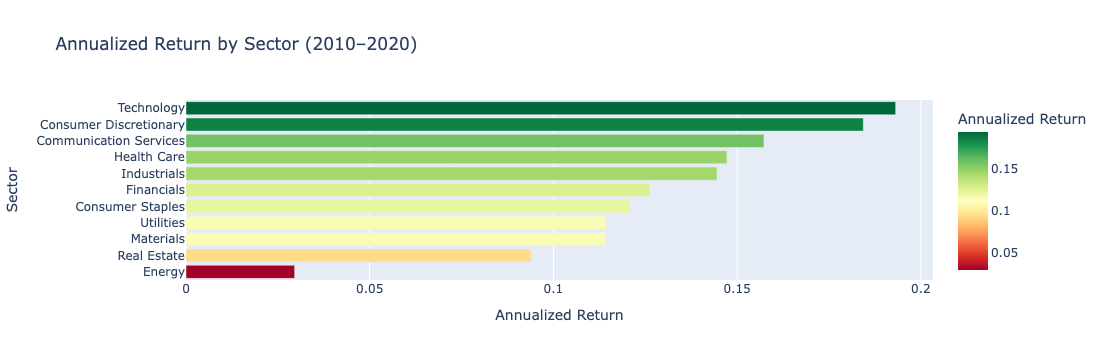

In [5]:
plot_sector_returns(summary).show()

### 3.2 Risk vs. Return

Bubble size represents Sharpe ratio. Upper-left quadrant = high return per unit of risk.

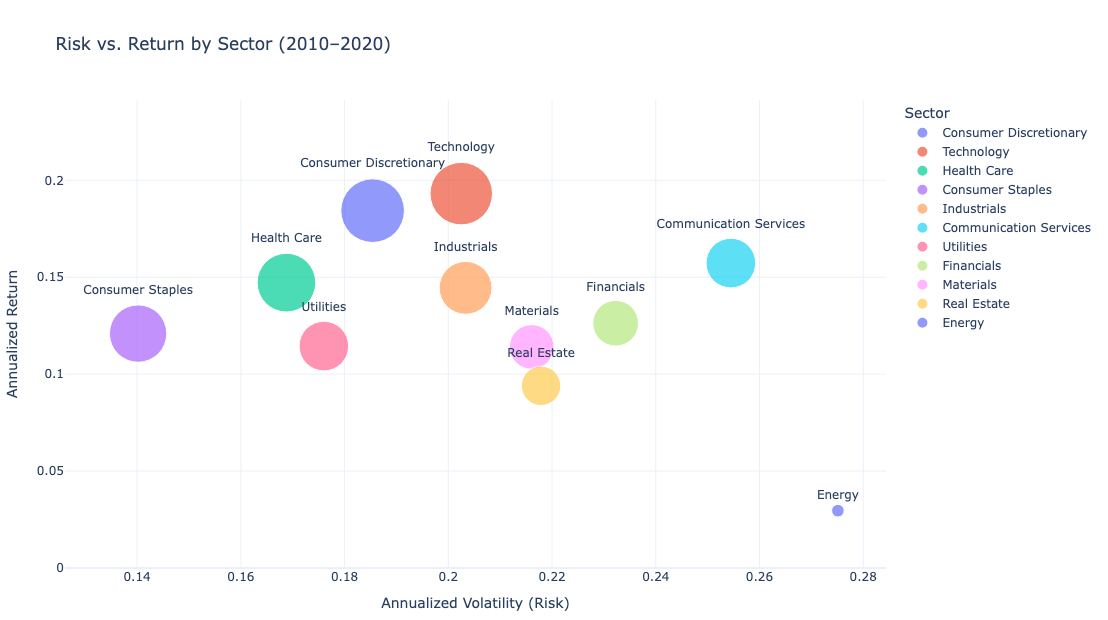

In [6]:
plot_risk_return_scatter(summary).show()

### 3.3 Sector Return Correlation Matrix

Values near 1 indicate sectors that move together, reducing diversification benefit.

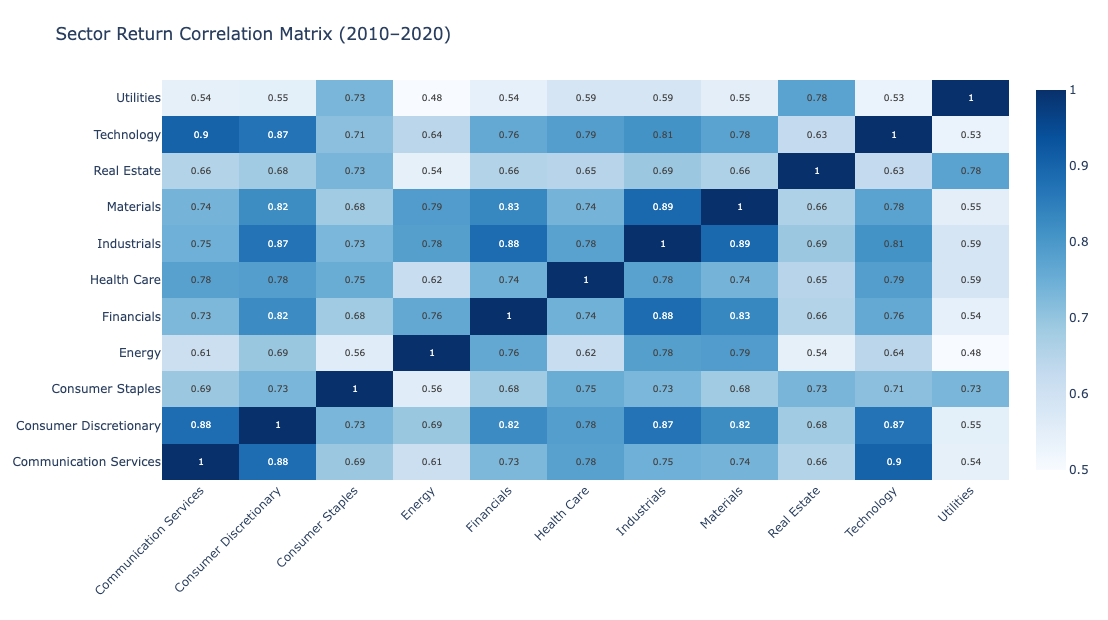

In [7]:
returns_wide = returns.pivot_table(index='date', columns='sector', values='daily_return')
plot_correlation_heatmap(returns_wide).show()

### 3.4 Rolling 252-Day Sharpe Ratio

Shows how risk-adjusted performance evolved over time. A drop below 0 means the sector was underperforming the risk-free rate on a trailing 1-year basis.

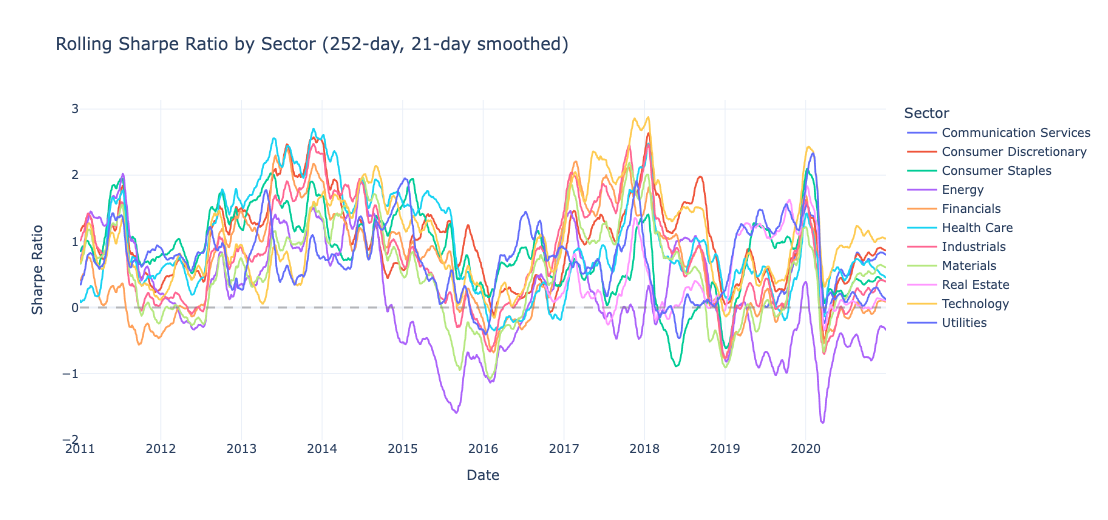

In [8]:
rolling = rolling_sharpe(returns)
plot_rolling_sharpe(rolling).show()

### 3.5 Efficient Frontier

3,000 randomly weighted sector portfolios, colored by Sharpe ratio. Stars mark the minimum-variance and maximum-Sharpe portfolios. Individual sectors are plotted in black for reference.

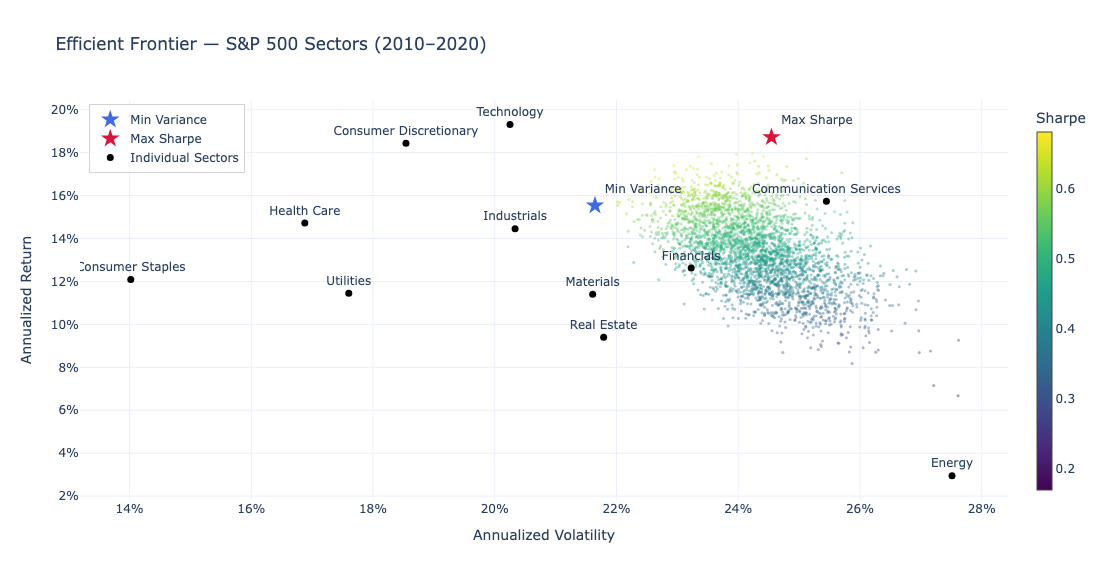

In [9]:
ef_df = efficient_frontier(returns)
plot_efficient_frontier(ef_df, summary).show()

## 4. Key Findings

| Sector | Takeaway |
|--------|----------|
| **Technology (XLK)** | Highest annualized return and Sharpe ratio — dominated the decade |
| **Energy (XLE)** | Worst performer; deep drawdowns driven by oil cycles and the 2020 demand collapse |
| **Health Care (XLV)** | Strong risk-adjusted returns with relatively low drawdown |
| **Utilities / Consumer Staples** | Lowest volatility; classic defensive characteristics |
| **Correlation structure** | Most sectors show moderate-to-high correlation (≥0.6), limiting intra-equity diversification |

### Rolling Sharpe Observations
- All sectors saw Sharpe ratios collapse in early 2020 (COVID crash), then recover sharply.
- Technology maintained a consistently high rolling Sharpe throughout 2013–2020.
- Energy's rolling Sharpe turned deeply negative during the 2015–2016 oil price crash.

### Efficient Frontier Observations
- The max-Sharpe portfolio concentrates heavily in Technology and Health Care.
- The min-variance portfolio tilts toward Consumer Staples and Utilities.
- Individual sectors all lie inside (or on) the frontier — diversification always helps.

**Takeaway:** The 2010–2020 period strongly favored growth sectors. A mean-variance efficient frontier would over-weight Technology and Health Care while minimizing Energy exposure.